In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
save_path="data_output/wholesale_price_utc12.csv"

wholesale_price = pd.read_csv("data_input/wholesale_prices.csv")

In [3]:
wholesale_price = wholesale_price[['Period start', 'Region ID', 'Price ($/MWh)']].rename(columns={
    'Period start': 'datetime',
    'Region ID': 'region_id',
    'Price ($/MWh)': 'price_dol/MWh'
})

In [4]:
wholesale_price['datetime'] = pd.to_datetime(wholesale_price['datetime'], dayfirst=True)

In [5]:
wholesale_price = wholesale_price.pivot(index='datetime', columns='region_id', values='price_dol/MWh')
wholesale_price.columns = [f'el_price_dol/MWh_{col}' for col in wholesale_price.columns]

In [6]:
wholesale_price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217416 entries, 2014-01-01 00:00:00 to 2026-05-27 12:30:00
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   el_price_dol/MWh_BEN2201  217416 non-null  float64
 1   el_price_dol/MWh_HAY2201  217416 non-null  float64
 2   el_price_dol/MWh_INV2201  217416 non-null  float64
 3   el_price_dol/MWh_ISL2201  217416 non-null  float64
 4   el_price_dol/MWh_KIK2201  144375 non-null  float64
 5   el_price_dol/MWh_OTA2201  217416 non-null  float64
 6   el_price_dol/MWh_RDF2201  217416 non-null  float64
 7   el_price_dol/MWh_SFD2201  217416 non-null  float64
 8   el_price_dol/MWh_WKM2201  217416 non-null  float64
dtypes: float64(9)
memory usage: 16.6 MB


In [7]:
# see all sub-30min rows across all years
print(wholesale_price[wholesale_price.index.minute.isin([40, 50])].index.tolist())

[Timestamp('2014-04-06 02:40:00'), Timestamp('2014-04-06 02:50:00'), Timestamp('2015-04-05 02:40:00'), Timestamp('2015-04-05 02:50:00'), Timestamp('2016-04-03 02:40:00'), Timestamp('2016-04-03 02:50:00'), Timestamp('2017-04-02 02:40:00'), Timestamp('2017-04-02 02:50:00'), Timestamp('2019-04-07 02:40:00'), Timestamp('2019-04-07 02:50:00'), Timestamp('2020-04-05 02:40:00'), Timestamp('2020-04-05 02:50:00'), Timestamp('2021-04-04 02:40:00'), Timestamp('2021-04-04 02:50:00'), Timestamp('2022-04-03 02:40:00'), Timestamp('2022-04-03 02:50:00'), Timestamp('2023-04-02 02:40:00'), Timestamp('2023-04-02 02:50:00'), Timestamp('2024-04-07 02:40:00'), Timestamp('2024-04-07 02:50:00'), Timestamp('2025-04-06 02:40:00'), Timestamp('2025-04-06 02:50:00'), Timestamp('2026-04-05 02:40:00'), Timestamp('2026-04-05 02:50:00')]


In [8]:
# Step 1: extract the sub-30min rows FROM ORIGINAL
extra_hour_data = wholesale_price[wholesale_price.index.minute.isin([40, 50])].copy()

# Step 2: drop them from original before we work on it
wholesale_price_clean = wholesale_price[~wholesale_price.index.minute.isin([40, 50])].copy()

# Step 3: convert clean original to fixed UTC+12
wholesale_price_utc12 = wholesale_price_clean.copy()
wholesale_price_utc12.index = (
    pd.to_datetime(wholesale_price_utc12.index)
    .tz_localize('Pacific/Auckland', ambiguous='NaT', nonexistent='NaT')
    .tz_convert('Etc/GMT-12')
    .tz_localize(None)
)

# Step 4: drop NaT rows
wholesale_price_utc12 = wholesale_price_utc12[wholesale_price_utc12.index.notna()]

# Step 5: remap 02:40 → 02:00, 02:50 → 02:30
extra_hour_data.index = extra_hour_data.index.map(
    lambda ts: ts.replace(minute=0 if ts.minute == 40 else 30)
)

# Step 6: reinsert and sort
wholesale_price_utc12 = pd.concat([wholesale_price_utc12, extra_hour_data]).sort_index()

# Step 7: verify
print(wholesale_price_utc12[wholesale_price_utc12.index.duplicated(keep=False)])

Empty DataFrame
Columns: [el_price_dol/MWh_BEN2201, el_price_dol/MWh_HAY2201, el_price_dol/MWh_INV2201, el_price_dol/MWh_ISL2201, el_price_dol/MWh_KIK2201, el_price_dol/MWh_OTA2201, el_price_dol/MWh_RDF2201, el_price_dol/MWh_SFD2201, el_price_dol/MWh_WKM2201]
Index: []


In [9]:
# see all sub-30min rows across all years
print(wholesale_price_utc12[wholesale_price_utc12.index.minute.isin([40, 50])].index.tolist())

[]


AttributeError: 'Axes' object has no attribute 'xa'

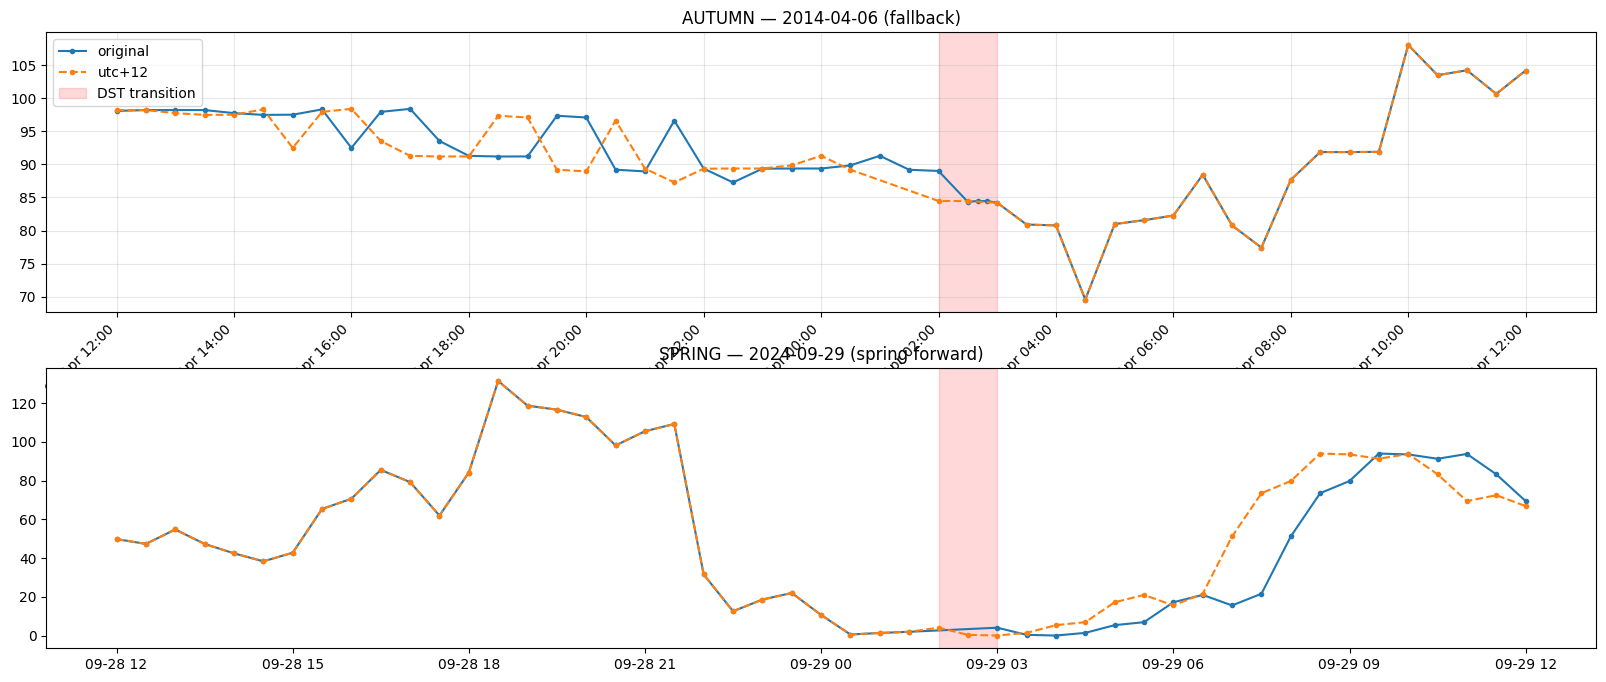

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

col = 'el_price_dol/MWh_BEN2201'

# --- SET DATES HERE ---
autumn_date = '2014-04-06'
spring_date = '2024-09-29'

# --- AUTUMN ---
aut_start = pd.Timestamp(autumn_date) - pd.Timedelta(hours=12)
aut_end   = pd.Timestamp(autumn_date) + pd.Timedelta(hours=12)
aut_orig  = wholesale_price[aut_start:aut_end][col]
aut_utc   = wholesale_price_utc12[aut_start:aut_end][col]

# --- SPRING ---
spr_start = pd.Timestamp(spring_date) - pd.Timedelta(hours=12)
spr_end   = pd.Timestamp(spring_date) + pd.Timedelta(hours=12)
spr_orig  = wholesale_price[spr_start:spr_end][col]
spr_utc   = wholesale_price_utc12[spr_start:spr_end][col]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))

# Autumn
ax1.plot(aut_orig.index, aut_orig.values, label='original', marker='o', markersize=3)
ax1.plot(aut_utc.index,  aut_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
ax1.axvspan(pd.Timestamp(autumn_date).replace(hour=2), pd.Timestamp(autumn_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
ax1.set_title(f'AUTUMN — {autumn_date} (fallback)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Spring
ax2.plot(spr_orig.index, spr_orig.values, label='original', marker='o', markersize=3)
ax2.plot(spr_utc.index,  spr_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
ax2.axvspan(pd.Timestamp(spring_date).replace(hour=2), pd.Timestamp(spring_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
ax2.set_title(f'SPRING — {spring_date} (spring forward)')
ax2.xa

In [ ]:
wholesale_price_utc12.reset_index(inplace=True)
wholesale_price_utc12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217390 entries, 0 to 217389
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   datetime                  217390 non-null  datetime64[ns]
 1   el_price_dol/MWh_BEN2201  217390 non-null  float64       
 2   el_price_dol/MWh_HAY2201  217390 non-null  float64       
 3   el_price_dol/MWh_INV2201  217390 non-null  float64       
 4   el_price_dol/MWh_ISL2201  217390 non-null  float64       
 5   el_price_dol/MWh_KIK2201  144357 non-null  float64       
 6   el_price_dol/MWh_OTA2201  217390 non-null  float64       
 7   el_price_dol/MWh_RDF2201  217390 non-null  float64       
 8   el_price_dol/MWh_SFD2201  217390 non-null  float64       
 9   el_price_dol/MWh_WKM2201  217390 non-null  float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 16.6 MB


In [ ]:
wholesale_price_utc12.describe()

,datetime,el_price_dol/MWh_BEN2201,el_price_dol/MWh_HAY2201,el_price_dol/MWh_INV2201,el_price_dol/MWh_ISL2201,el_price_dol/MWh_KIK2201,el_price_dol/MWh_OTA2201,el_price_dol/MWh_RDF2201,el_price_dol/MWh_SFD2201,el_price_dol/MWh_WKM2201
count,217390,217390.000000,217390.000000,217390.000000,217390.000000,144357.000000,217390.000000,217390.000000,217390.000000,217390.000000
mean,2020-03-14 17:21:08.280049920,105.568978,110.521049,107.594827,113.268001,139.181692,116.875030,110.648884,109.590567,110.570188
min,2013-12-31 23:00:00,0.000000,0.000000,-0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-02-06 07:37:30,48.300000,52.112500,47.160000,51.170000,57.780000,56.210000,53.600000,53.260000,53.580000
50%,2020-03-14 17:15:00,78.350000,82.660000,78.445000,83.560000,114.860000,88.200000,83.820000,83.210000,83.910000
75%,2023-04-21 02:52:30,138.990000,145.040000,140.880000,148.690000,192.020000,154.980000,146.497500,144.940000,146.440000
max,2026-05-27 12:30:00,8016.330000,8714.530000,8061.890000,8870.700000,4958.880000,9676.770000,8703.100000,8995.030000,8869.790000
std,NaN,102.772436,107.689245,106.440796,111.636533,129.629945,113.057778,106.981984,104.806608,105.627803


In [ ]:
wholesale_price_utc12.to_csv(save_path, index=False)
print(f"✅ wholesale_price has been cleaned and saved under {save_path} ✅")

✅ wholesale_price has been cleaned and saved under data_output/wholesale_price_utc12.csv ✅
